In [59]:
%%writefile utils_segmentation.py
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

def otsu_threshold(image_gray):
    image_gray = np.clip(image_gray, 0, 255).astype(np.uint8)
    pixel_counts = np.bincount(image_gray.ravel(), minlength=256)
    pixel_probas = pixel_counts / max(len(image_gray.ravel()), 1)
    q_b = np.cumsum(pixel_probas)
    q_f = 1.0 - q_b
    valid = (q_b > 0) & (q_f > 0)
    val_range = np.arange(256)
    m_b = np.cumsum(val_range * pixel_probas) / (q_b + 1e-10)
    m_f = (np.sum(val_range * pixel_probas) - np.cumsum(val_range * pixel_probas)) / (q_f + 1e-10)
    var_between = q_b * q_f * (m_b - m_f) ** 2
    if not np.any(valid):
        return 127
    return np.argmax(var_between * valid)

def otsu_tissue_mask(img_rgb):
    img_gray = np.mean(img_rgb, axis=2).astype(np.uint8)
    threshold = otsu_threshold(img_gray)
    return (img_gray < threshold).astype(np.uint8)

def normalize_stain_macenko(img, io=240, beta=0.15, alpha=1):
    img = np.array(img, dtype=np.float32)
    img_clipped = np.clip(img, 1.0, 255.0)
    od = -np.log10(img_clipped / io)
    od_flat = od.reshape(-1, 3)
    mask = np.any(od_flat > beta, axis=1)
    od_hat = od_flat[mask]
    if len(od_hat) < 100:
        return img.astype(np.uint8)
    cov = np.cov(od_hat, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    v = eigvecs[:, [2, 1]]
    proj = np.dot(od_hat, v)
    angles = np.arctan2(proj[:, 1], proj[:, 0])
    min_angle = np.percentile(angles, alpha)
    max_angle = np.percentile(angles, 100 - alpha)
    v_h = np.dot(v, np.array([np.cos(min_angle), np.sin(min_angle)]))
    v_e = np.dot(v, np.array([np.cos(max_angle), np.sin(max_angle)]))
    stain_matrix = np.array([v_e, v_h]).T if v_h[0] < v_e[0] else np.array([v_h, v_e]).T
    stain_matrix_inv = np.linalg.pinv(stain_matrix)
    concentration = np.dot(stain_matrix_inv, od_flat.T)
    max_concentration = np.percentile(concentration, 99, axis=1, keepdims=True)
    ref_stain_matrix = np.array([[0.5626, 0.2137], [0.7201, 0.8010], [0.4062, 0.5580]])
    ref_max_concentration = np.array([[1.9705], [1.0308]])
    normalized_concentration = concentration * (ref_max_concentration / (max_concentration + 1e-8))
    normalized_od = np.dot(ref_stain_matrix, normalized_concentration)
    normalized_img = io * np.power(10, -normalized_od)
    normalized_img = normalized_img.T.reshape(img.shape)
    return np.clip(normalized_img, 0.0, 255.0).astype(np.uint8)

class WSI_Simulator:
    def __init__(self, size=1024, seed=42):
        self.size = size
        self.seed = seed
        np.random.seed(seed)
    def generate_slide(self):
        bg_noise = np.random.randint(-5, 5, (self.size, self.size, 3))
        bg = np.ones((self.size, self.size, 3), dtype=np.uint8) * np.array([242, 238, 240], dtype=np.uint8)
        bg = np.clip(bg.astype(np.int16) + bg_noise, 0, 255).astype(np.uint8)
        grid_size = 16
        low_res = np.random.rand(grid_size, grid_size)
        low_res_img = Image.fromarray((low_res * 255).astype(np.uint8))
        tissue_probability = np.array(low_res_img.resize((self.size, self.size), Image.BILINEAR)) / 255.0
        tissue_mask = (tissue_probability > 0.4).astype(np.uint8)
        low_res_tumor = np.random.rand(grid_size, grid_size)
        low_res_tumor_img = Image.fromarray((low_res_tumor * 255).astype(np.uint8))
        tumor_probability = np.array(low_res_tumor_img.resize((self.size, self.size), Image.BILINEAR)) / 255.0
        tumor_mask = ((tumor_probability > 0.55) & (tissue_mask == 1)).astype(np.uint8)
        stroma_color = np.array([230, 185, 210])
        tissue_indices = np.where(tissue_mask == 1)
        bg[tissue_indices[0], tissue_indices[1]] = stroma_color
        num_nuclei = 4000
        for _ in range(num_nuclei):
            cx = np.random.randint(10, self.size - 10)
            cy = np.random.randint(10, self.size - 10)
            if tissue_mask[cy, cx] == 0:
                continue
            is_tumor_spot = tumor_mask[cy, cx] == 1
            if is_tumor_spot:
                radius = np.random.randint(5, 9)
                n_color = np.array([np.random.randint(20, 60), np.random.randint(15, 45), np.random.randint(100, 140)])
            else:
                if np.random.rand() > 0.4:
                    continue
                radius = np.random.randint(3, 5)
                n_color = np.array([np.random.randint(70, 110), np.random.randint(50, 80), np.random.randint(130, 170)])
            y, x = np.ogrid[-cy:self.size-cy, -cx:self.size-cx]
            mask = x*x + y*y <= radius*radius
            bg[mask] = n_color
        return bg, tumor_mask

class TissuePatchDataset(Dataset):
    def __init__(self, images, masks, patch_size=128, stride=64, transform=None, stain_norm=False):
        self.patch_size = patch_size
        self.transform = transform
        self.stain_norm = stain_norm
        self.patches = []
        self.masks = []
        for img, mask in zip(images, masks):
            h, w, _ = img.shape
            tissue_mask = otsu_tissue_mask(img)
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    tissue_ratio = np.mean(tissue_mask[y:y+patch_size, x:x+patch_size])
                    if tissue_ratio < 0.15:
                        continue
                    self.patches.append(img[y:y+patch_size, x:x+patch_size])
                    self.masks.append(mask[y:y+patch_size, x:x+patch_size])
        print(f"Extracted {len(self.patches)} valid patches of size {patch_size}x{patch_size}.")
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        img_np = self.patches[idx]
        mask_np = self.masks[idx]
        if self.stain_norm:
            try:
                img_np = normalize_stain_macenko(img_np)
            except:
                pass
        img_pil = Image.fromarray(img_np)
        mask_pil = Image.fromarray((mask_np * 255).astype(np.uint8))
        if self.transform:
            state = torch.get_rng_state()
            img_tensor = self.transform(img_pil)
            torch.set_rng_state(state)
            mask_transform_list = []
            for t in self.transform.transforms:
                if isinstance(t, (transforms.RandomHorizontalFlip, transforms.RandomVerticalFlip, transforms.RandomRotation)):
                    mask_transform_list.append(t)
            mask_transform = transforms.Compose(mask_transform_list) if mask_transform_list else lambda x: x
            mask_pil_aug = mask_transform(mask_pil)
            mask_np_aug = np.array(mask_pil_aug)
            mask_tensor = torch.tensor(mask_np_aug > 127, dtype=torch.float32).unsqueeze(0)
        else:
            from torchvision.transforms import functional as F
            img_tensor = F.to_tensor(img_pil)
            mask_tensor = torch.tensor(mask_np > 0, dtype=torch.float32).unsqueeze(0)
        return img_tensor, mask_tensor

Overwriting utils_segmentation.py


In [60]:
%%writefile unet_model.py
import torch
import torch.nn as nn
from torchvision import models

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = nn.functional.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class ResNetUNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        layers = list(resnet.children())
        
        self.layer0 = nn.Sequential(*layers[:3])
        self.layer0_1 = layers[3]
        self.layer1 = layers[4]
        self.layer2 = layers[5]
        self.layer3 = layers[6]
        self.layer4 = layers[7]

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(256 + 256, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128 + 128, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(64 + 64, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(64 + 64, 32)
        
        self.up0 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.conv_up0 = DoubleConv(32, 16)
        
        self.out_conv = nn.Conv2d(16, n_class, kernel_size=1)

    def forward(self, x):
        x0 = self.layer0(x)
        x0_1 = self.layer0_1(x0)
        x1 = self.layer1(x0_1)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        y4 = self.up4(x4)
        y4 = torch.cat([y4, x3], dim=1)
        y4 = self.conv_up4(y4)

        y3 = self.up3(y4)
        y3 = torch.cat([y3, x2], dim=1)
        y3 = self.conv_up3(y3)

        y2 = self.up2(y3)
        y2 = torch.cat([y2, x1], dim=1)
        y2 = self.conv_up2(y2)

        y1 = self.up1(y2)
        if y1.shape[2:] != x0.shape[2:]:
            x0 = nn.functional.interpolate(x0, size=y1.shape[2:], mode='bilinear', align_corners=True)
        y1 = torch.cat([y1, x0], dim=1)
        y1 = self.conv_up1(y1)

        y0 = self.up0(y1)
        y0 = self.conv_up0(y0)

        out = self.out_conv(y0)
        return out

class AttentionUNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        layers = list(resnet.children())
        
        self.layer0 = nn.Sequential(*layers[:3])
        self.layer0_1 = layers[3]
        self.layer1 = layers[4]
        self.layer2 = layers[5]
        self.layer3 = layers[6]
        self.layer4 = layers[7]

        self.att4 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.att2 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(256 + 256, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128 + 128, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(64 + 64, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(64 + 64, 32)
        
        self.up0 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.conv_up0 = DoubleConv(32, 16)
        
        self.out_conv = nn.Conv2d(16, n_class, kernel_size=1)

    def forward(self, x):
        x0 = self.layer0(x)
        x0_1 = self.layer0_1(x0)
        x1 = self.layer1(x0_1)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        y4 = self.up4(x4)
        x3_att = self.att4(g=y4, x=x3)
        y4 = torch.cat([y4, x3_att], dim=1)
        y4 = self.conv_up4(y4)

        y3 = self.up3(y4)
        x2_att = self.att3(g=y3, x=x2)
        y3 = torch.cat([y3, x2_att], dim=1)
        y3 = self.conv_up3(y3)

        y2 = self.up2(y3)
        x1_att = self.att2(g=y2, x=x1)
        y2 = torch.cat([y2, x1_att], dim=1)
        y2 = self.conv_up2(y2)

        y1 = self.up1(y2)
        if y1.shape[2:] != x0.shape[2:]:
            x0 = nn.functional.interpolate(x0, size=y1.shape[2:], mode='bilinear', align_corners=True)
        x0_att = self.att1(g=y1, x=x0)
        y1 = torch.cat([y1, x0_att], dim=1)
        y1 = self.conv_up1(y1)

        y0 = self.up0(y1)
        y0 = self.conv_up0(y0)

        out = self.out_conv(y0)
        return out

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, inputs, targets, smooth=1e-6):
        bce_loss = self.bce(inputs, targets)
        probs = torch.sigmoid(inputs)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice_coeff = (2.0 * intersection + smooth) / (probs_flat.sum() + targets_flat.sum() + smooth)
        dice_loss = 1.0 - dice_coeff
        return bce_loss + dice_loss

Overwriting unet_model.py


In [61]:
# Import dependencies and check GPU availability
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

# Import custom modular helpers (ensure utils_segmentation.py & unet_model.py are in working directory)
from utils_segmentation import WSI_Simulator, TissuePatchDataset, otsu_tissue_mask, normalize_stain_macenko
from unet_model import ResNetUNet, AttentionUNet, DiceBCELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Model: Tesla T4


In [62]:
import glob
import cv2
import os
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms  # <-- Added this import
from utils_segmentation import TissuePatchDataset

# 1. DEFINE TRANSFORMS (in case previous cells were not run)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Glob paths matching the Kumar dataset structure
image_glob = "/kaggle/input/datasets/ayush02102001/tnbc-seg/Kumar/kumar/train/Images/*.tif"
mask_glob = "/kaggle/input/datasets/ayush02102001/tnbc-seg/Kumar/kumar/train/Overlay/*.png"

image_paths_raw = glob.glob(image_glob)
mask_paths_raw = glob.glob(mask_glob)

# 3. Pair matching images and masks by their file prefix
image_map = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths_raw}
mask_map = {os.path.splitext(os.path.basename(p))[0]: p for p in mask_paths_raw}

common_keys = sorted(list(set(image_map.keys()) & set(mask_map.keys())))

image_paths = [image_map[k] for k in common_keys]
mask_paths = [mask_map[k] for k in common_keys]

print(f"Total .tif images found: {len(image_paths_raw)}")
print(f"Total .png masks found:  {len(mask_paths_raw)}")
print(f"Successfully matched:    {len(image_paths)} image-mask pairs.")

# 4. Read paired files into memory
real_images = []
real_masks = []

print("\nLoading paired Kumar slides into memory...")
for img_path, mask_path in zip(image_paths, mask_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Read mask as grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.uint8) # binarize mask
    
    real_images.append(img)
    real_masks.append(mask)

print(f"Loaded {len(real_images)} slides into memory.")

# 5. Extract patches and load into DataLoader
train_dataset = TissuePatchDataset(real_images, real_masks, patch_size=128, stride=64, transform=train_transform, stain_norm=True)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print(f"✅ train_loader created successfully with {len(train_loader)} batches!")

Total .tif images found: 16
Total .png masks found:  16
Successfully matched:    16 image-mask pairs.

Loading paired Kumar slides into memory...
Loaded 16 slides into memory.
Extracted 3080 valid patches of size 128x128.
✅ train_loader created successfully with 193 batches!


In [63]:
# Generate multiple slides to build a robust dataset
train_slides, train_masks = [], []
for seed in [101, 102, 103]:
    sim = WSI_Simulator(size=1024, seed=seed)
    s, m = sim.generate_slide()
    train_slides.append(s)
    train_masks.append(m)

val_slides, val_masks = [], []
for seed in [201]:
    sim = WSI_Simulator(size=1024, seed=seed)
    s, m = sim.generate_slide()
    val_slides.append(s)
    val_masks.append(m)

# Define spatial augmentations
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create patch datasets (stride = 64 for overlap)
print("Extracting training patches...")
train_dataset = TissuePatchDataset(train_slides, train_masks, patch_size=128, stride=64, transform=train_transform, stain_norm=True)

print("\nExtracting validation patches...")
val_dataset = TissuePatchDataset(val_slides, val_masks, patch_size=128, stride=64, transform=val_test_transform, stain_norm=True)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"\nTrain Loader: {len(train_loader)} batches.")
print(f"Validation Loader: {len(val_loader)} batches.")

Extracting training patches...
Extracted 210 valid patches of size 128x128.

Extracting validation patches...
Extracted 82 valid patches of size 128x128.

Train Loader: 14 batches.
Validation Loader: 6 batches.


In [64]:
# Choose model: standard U-Net ('unet') or Attention U-Net ('attention')
model_type = "unet"  # change to "attention" to train Attention U-Net

if model_type == "unet":
    model = ResNetUNet(n_class=1).to(device)
else:
    model = AttentionUNet(n_class=1).to(device)

criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

print(f"Model '{model_type}' initialized and loaded to {device}.")

Model 'unet' initialized and loaded to cuda.


Generating simulated tissue slide with Seed: 456...


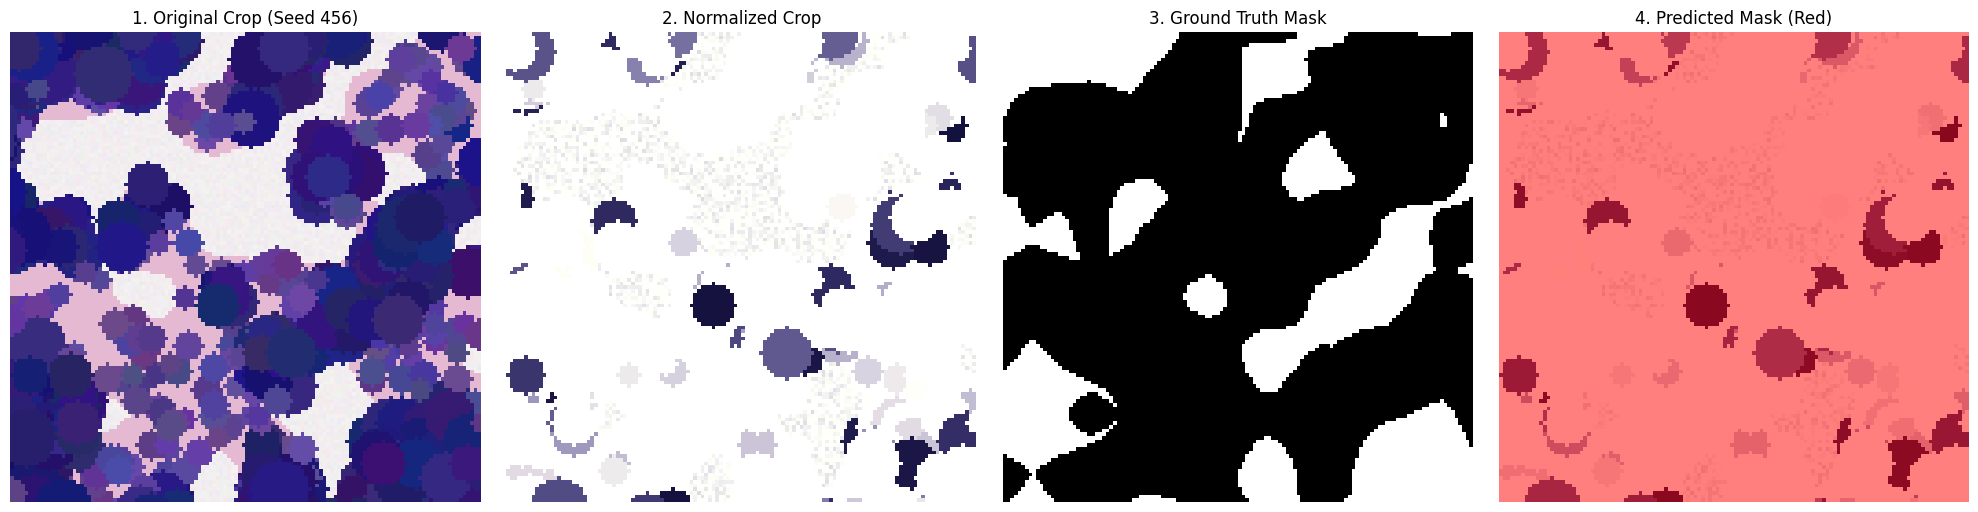

Accuracy Metric for this Crop:
 -> Dice Overlap Coefficient: 42.18%


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from utils_segmentation import WSI_Simulator, normalize_stain_macenko

# 1. Device Setup
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Check if the trained model exists in memory
if 'model' not in globals():
    raise NameError("The U-Net model was not found. Please run your training cell (Cell 6) first.")

# -------------------------------------------------------------
# CHANGE THIS SEED TO GENERATE & TEST A DIFFERENT TISSUE SLIDE
# -------------------------------------------------------------
slide_seed = 456  # You can change this to 555, 777, 888, etc.

print(f"Generating simulated tissue slide with Seed: {slide_seed}...")
test_sim = WSI_Simulator(size=256, seed=slide_seed)
test_slide, test_mask = test_sim.generate_slide()

# Crop a 128x128 patch from the center of the generated slide
crop_img = test_slide[64:192, 64:192]
crop_gt_mask = test_mask[64:192, 64:192]

# 3. Apply Stain Normalization
try:
    normalized_img = normalize_stain_macenko(crop_img)
    processed_img = Image.fromarray(normalized_img)
except Exception as e:
    print(f"Stain normalization failed: {e}. Using raw crop.")
    processed_img = Image.fromarray(crop_img)
    normalized_img = crop_img

# 4. Run U-Net Inference
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = eval_transform(processed_img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probabilities = torch.sigmoid(outputs).squeeze().cpu().numpy()
    binary_mask = (probabilities > 0.5).astype(np.uint8)

# 5. Plot the results: Original, Ground Truth Mask, and Predicted Overlay
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1: Original Image
axes[0].imshow(crop_img)
axes[0].set_title(f"1. Original Crop (Seed {slide_seed})", fontsize=12)
axes[0].axis('off')

# Panel 2: Normalized Image
axes[1].imshow(normalized_img)
axes[1].set_title("2. Normalized Crop", fontsize=12)
axes[1].axis('off')

# Panel 3: Ground Truth Tumor Mask
axes[2].imshow(crop_gt_mask, cmap='gray')
axes[2].set_title("3. Ground Truth Mask", fontsize=12)
axes[2].axis('off')

# Panel 4: Predicted Mask Overlay
overlay = np.copy(normalized_img)
overlay[binary_mask == 1] = [255, 0, 0] # Color predicted tumor pixels red
blended = (normalized_img * 0.5 + overlay * 0.5).astype(np.uint8)

axes[3].imshow(blended)
axes[3].set_title("4. Predicted Mask (Red)", fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 6. Print Dice Score for this specific crop
intersection = np.sum((binary_mask == 1) & (crop_gt_mask == 1))
union_sum = np.sum(binary_mask) + np.sum(crop_gt_mask)
dice = (2.0 * intersection) / (union_sum + 1e-8)
print(f"Accuracy Metric for this Crop:")
print(f" -> Dice Overlap Coefficient: {dice * 100:.2f}%")

In [66]:
def calculate_metrics(pred_logits, targets, threshold=0.5, smooth=1e-6):
    preds = (torch.sigmoid(pred_logits) > threshold).float()
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)
    
    intersection = (preds_flat * targets_flat).sum().item()
    union = preds_flat.sum().item() + targets_flat.sum().item() - intersection
    
    dice = (2.0 * intersection + smooth) / (preds_flat.sum().item() + targets_flat.sum().item() + smooth)
    iou = (intersection + smooth) / (union + smooth)
    return dice, iou

epochs = 5
print("Starting Segmentation Model Training...")
for epoch in range(epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    train_dice, train_iou = [], []
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        d, i = calculate_metrics(outputs, masks)
        train_dice.append(d)
        train_iou.append(i)
        
    epoch_loss = train_loss / len(train_dataset)
    mean_tdice = np.mean(train_dice)
    mean_tiou = np.mean(train_iou)
    
    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_dice, val_iou = [], []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            val_loss += loss.item() * images.size(0)
            d, i = calculate_metrics(outputs, masks)
            val_dice.append(d)
            val_iou.append(i)
            
    epoch_val_loss = val_loss / len(val_dataset)
    mean_vdice = np.mean(val_dice)
    mean_viou = np.mean(val_iou)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {epoch_loss:.4f} Dice: {mean_tdice:.4f} IoU: {mean_tiou:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Dice: {mean_vdice:.4f} IoU: {mean_viou:.4f}")

Starting Segmentation Model Training...
Epoch 1/5 | Train Loss: 1.1393 Dice: 0.6424 IoU: 0.4812 | Val Loss: 1.2104 Dice: 0.6350 IoU: 0.4669
Epoch 2/5 | Train Loss: 0.9515 Dice: 0.8072 IoU: 0.6778 | Val Loss: 1.0457 Dice: 0.8009 IoU: 0.6703
Epoch 3/5 | Train Loss: 0.8709 Dice: 0.8349 IoU: 0.7178 | Val Loss: 0.8950 Dice: 0.8352 IoU: 0.7192
Epoch 4/5 | Train Loss: 0.8333 Dice: 0.8372 IoU: 0.7239 | Val Loss: 0.8021 Dice: 0.8421 IoU: 0.7289
Epoch 5/5 | Train Loss: 0.8041 Dice: 0.8442 IoU: 0.7318 | Val Loss: 0.7764 Dice: 0.8453 IoU: 0.7329


Reconstructing whole-slide tumor probability heatmap...


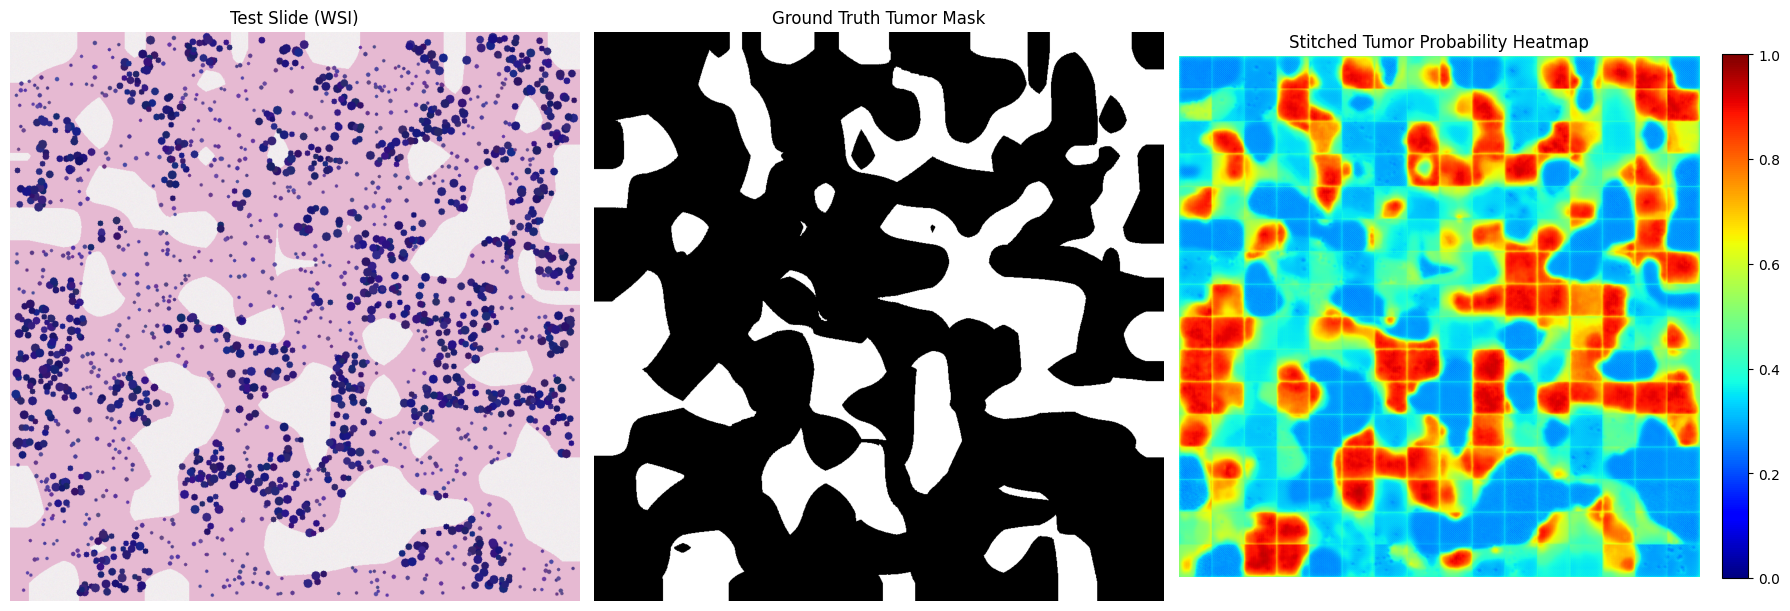

In [67]:
def reconstruct_heatmap(slide_img, model, patch_size=128, stride=64):
    h, w, _ = slide_img.shape
    heatmap = np.zeros((h, w), dtype=np.float32)
    weights = np.zeros((h, w), dtype=np.float32)
    
    model.eval()
    patch_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    with torch.no_grad():
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                crop = slide_img[y:y+patch_size, x:x+patch_size]
                try:
                    crop = normalize_stain_macenko(crop)
                except:
                    pass
                img_tensor = patch_transform(crop).unsqueeze(0).to(device)
                pred_logits = model(img_tensor)
                pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()
                
                heatmap[y:y+patch_size, x:x+patch_size] += pred_probs
                weights[y:y+patch_size, x:x+patch_size] += 1.0
                
    weights = np.clip(weights, 1.0, None)
    return heatmap / weights

# Generate test slide (seed 301)
test_sim = WSI_Simulator(size=1024, seed=301)
test_slide, test_mask = test_sim.generate_slide()

# Reconstruct heatmap
print("Reconstructing whole-slide tumor probability heatmap...")
prob_heatmap = reconstruct_heatmap(test_slide, model)

# Plot original, ground truth, and prediction heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(test_slide)
axes[0].set_title("Test Slide (WSI)")
axes[0].axis("off")

axes[1].imshow(test_mask, cmap="gray")
axes[1].set_title("Ground Truth Tumor Mask")
axes[1].axis("off")

im = axes[2].imshow(prob_heatmap, cmap="jet", vmin=0, vmax=1)
axes[2].set_title("Stitched Tumor Probability Heatmap")
axes[2].axis("off")

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Extracted 116 valid patches of size 128x128.
Running Ablation evaluation on color-shifted patches...


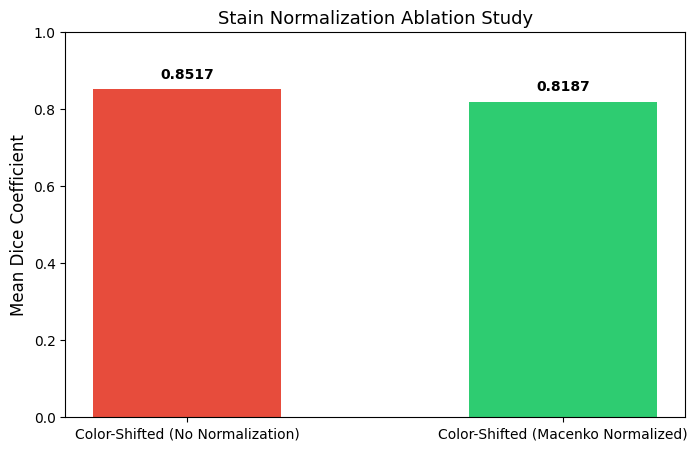

In [68]:
def apply_color_shift(img_np):
    img_shifted = img_np.astype(np.float32)
    img_shifted[..., 0] *= 0.85 # decrease red
    img_shifted[..., 1] *= 1.15 # increase green
    img_shifted[..., 2] *= 0.90 # decrease blue
    return np.clip(img_shifted, 0, 255).astype(np.uint8)

ablation_dataset_raw = TissuePatchDataset([test_slide], [test_mask], patch_size=128, stride=64, transform=None)

dice_no_norm = []
dice_with_norm = []

model.eval()
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Running Ablation evaluation on color-shifted patches...")
with torch.no_grad():
    for img_np, mask_np in zip(ablation_dataset_raw.patches, ablation_dataset_raw.masks):
        img_shifted = apply_color_shift(img_np)
        
        # 1. Evaluated without stain normalization
        img_tensor_no = eval_transform(Image.fromarray(img_shifted)).unsqueeze(0).to(device)
        mask_tensor = torch.tensor(mask_np > 0, dtype=torch.float32).unsqueeze(0).to(device)
        out_no = model(img_tensor_no)
        d_no, _ = calculate_metrics(out_no, mask_tensor)
        dice_no_norm.append(d_no)
        
        # 2. Evaluated with Macenko stain normalization
        try:
            img_norm = normalize_stain_macenko(img_shifted)
        except:
            img_norm = img_shifted
        img_tensor_with = eval_transform(Image.fromarray(img_norm)).unsqueeze(0).to(device)
        out_with = model(img_tensor_with)
        d_with, _ = calculate_metrics(out_with, mask_tensor)
        dice_with_norm.append(d_with)

mean_dice_no_norm = np.mean(dice_no_norm)
mean_dice_with_norm = np.mean(dice_with_norm)

# Plot ablation study
categories = ['Color-Shifted (No Normalization)', 'Color-Shifted (Macenko Normalized)']
scores = [mean_dice_no_norm, mean_dice_with_norm]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, scores, color=['#e74c3c', '#2ecc71'], width=0.5)
plt.ylabel('Mean Dice Coefficient', fontsize=12)
plt.title('Stain Normalization Ablation Study', fontsize=13)
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()

Extracted 116 valid patches of size 128x128.


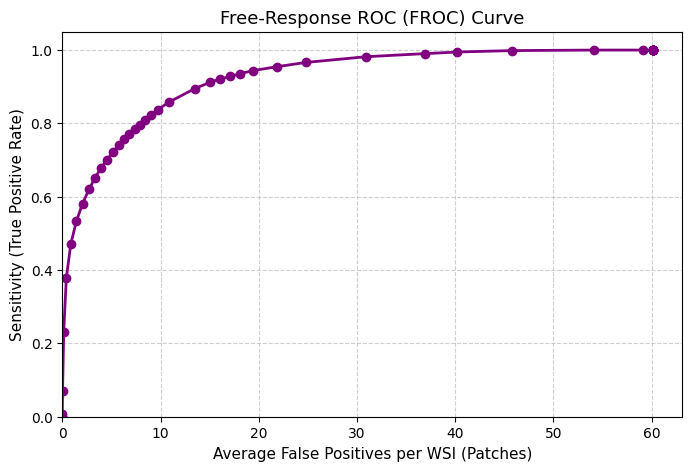

In [69]:
thresholds = np.linspace(0.01, 0.99, 50)
sensitivities = []
false_positives = []

test_dataset_patches = TissuePatchDataset([test_slide], [test_mask], patch_size=128, stride=64, transform=val_test_transform, stain_norm=True)
test_loader_patches = DataLoader(test_dataset_patches, batch_size=16, shuffle=False)

all_probs = []
all_masks = []

model.eval()
with torch.no_grad():
    for images, masks in test_loader_patches:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy().reshape(-1))
        all_masks.extend(masks.numpy().reshape(-1))

all_probs = np.array(all_probs)
all_masks = np.array(all_masks)

for th in thresholds:
    preds = (all_probs > th).astype(np.float32)
    tp = np.sum((preds == 1) & (all_masks == 1))
    fn = np.sum((preds == 0) & (all_masks == 1))
    sens = tp / (tp + fn + 1e-8)
    
    fp = np.sum((preds == 1) & (all_masks == 0))
    avg_fp = fp / (128 * 128)
    
    sensitivities.append(sens)
    false_positives.append(avg_fp)

# Plot FROC
plt.figure(figsize=(8, 5))
plt.plot(false_positives, sensitivities, marker='o', color='purple', linewidth=2)
plt.xlabel('Average False Positives per WSI (Patches)', fontsize=11)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=11)
plt.title('Free-Response ROC (FROC) Curve', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, max(false_positives)*1.05)
plt.ylim(0, 1.05)
plt.show()

Generating a test slide crop for evaluation...


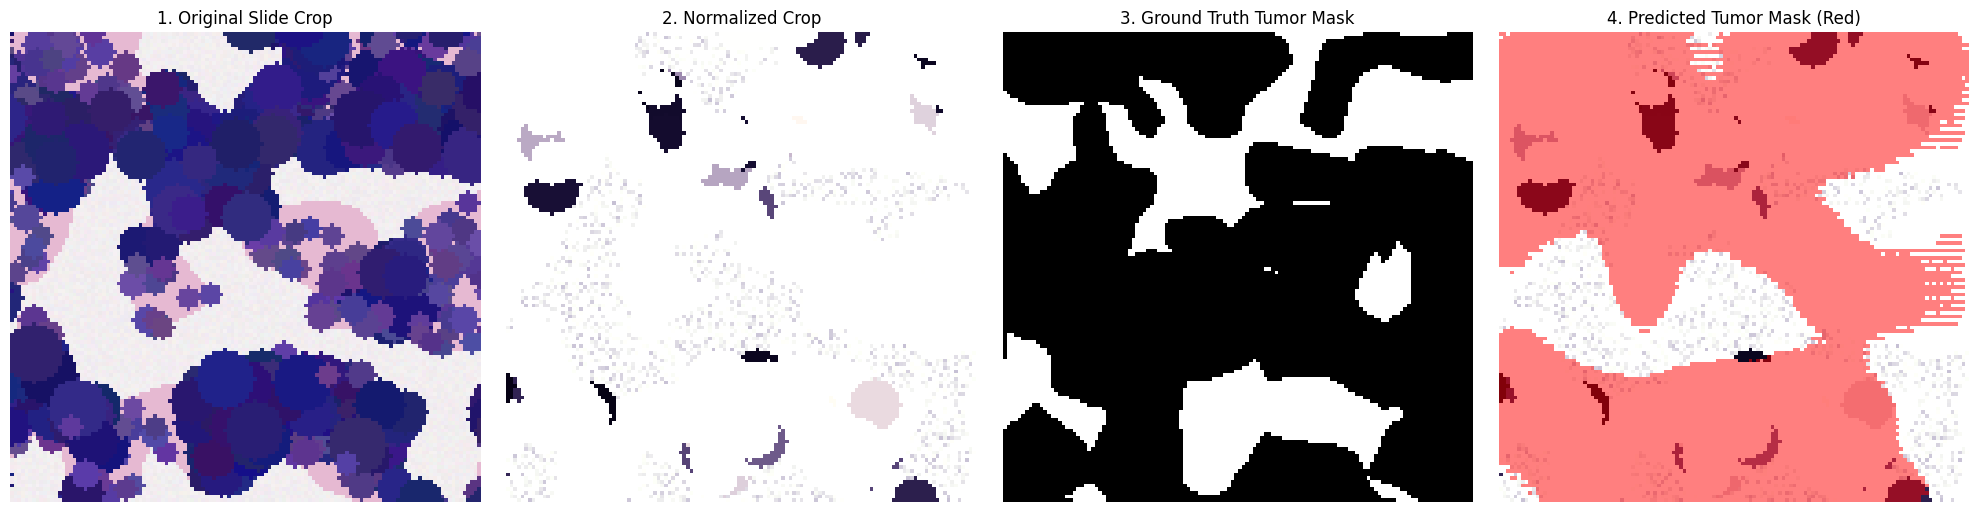

Accuracy Metric for this Crop:
 -> Dice Overlap Coefficient: 51.41%


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from utils_segmentation import WSI_Simulator, normalize_stain_macenko

# 1. Device Setup
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Check if the trained model exists in memory
if 'model' not in globals():
    raise NameError("The U-Net model was not found. Please run your training cell (Cell 6) first.")

# 3. Generate a fresh, random slide crop on-the-fly
print("Generating a test slide crop for evaluation...")
test_sim = WSI_Simulator(size=256, seed=999) # Create a small 256x256 slide
test_slide, test_mask = test_sim.generate_slide()

# Crop a 128x128 patch from the center of the generated slide
crop_img = test_slide[64:192, 64:192]
crop_gt_mask = test_mask[64:192, 64:192]

# 4. Apply Stain Normalization
try:
    normalized_img = normalize_stain_macenko(crop_img)
    processed_img = Image.fromarray(normalized_img)
except Exception as e:
    print(f"Stain normalization failed: {e}. Using raw crop.")
    processed_img = Image.fromarray(crop_img)
    normalized_img = crop_img

# 5. Run U-Net Inference
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = eval_transform(processed_img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probabilities = torch.sigmoid(outputs).squeeze().cpu().numpy()
    binary_mask = (probabilities > 0.5).astype(np.uint8)

# 6. Plot the results: Original, Ground Truth Mask, and Predicted Overlay
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original Image
axes[0].imshow(crop_img)
axes[0].set_title("1. Original Slide Crop", fontsize=12)
axes[0].axis('off')

# Normalized Image
axes[1].imshow(normalized_img)
axes[1].set_title("2. Normalized Crop", fontsize=12)
axes[1].axis('off')

# Ground Truth Tumor Mask
axes[2].imshow(crop_gt_mask, cmap='gray')
axes[2].set_title("3. Ground Truth Tumor Mask", fontsize=12)
axes[2].axis('off')

# Predicted Mask Overlay
overlay = np.copy(normalized_img)
overlay[binary_mask == 1] = [255, 0, 0] # Color predicted tumor pixels red
blended = (normalized_img * 0.5 + overlay * 0.5).astype(np.uint8)

axes[3].imshow(blended)
axes[3].set_title("4. Predicted Tumor Mask (Red)", fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 7. Print Dice Score for this specific crop
intersection = np.sum((binary_mask == 1) & (crop_gt_mask == 1))
union_sum = np.sum(binary_mask) + np.sum(crop_gt_mask)
dice = (2.0 * intersection) / (union_sum + 1e-8)
print(f"Accuracy Metric for this Crop:")
print(f" -> Dice Overlap Coefficient: {dice * 100:.2f}%")

🎲 Random Selection:
 -> Slide Index: [3] (TCGA-B0-5710-01Z-00-DX1.tif)
 -> Crop Center: (545, 807)
--------------------------------------------------


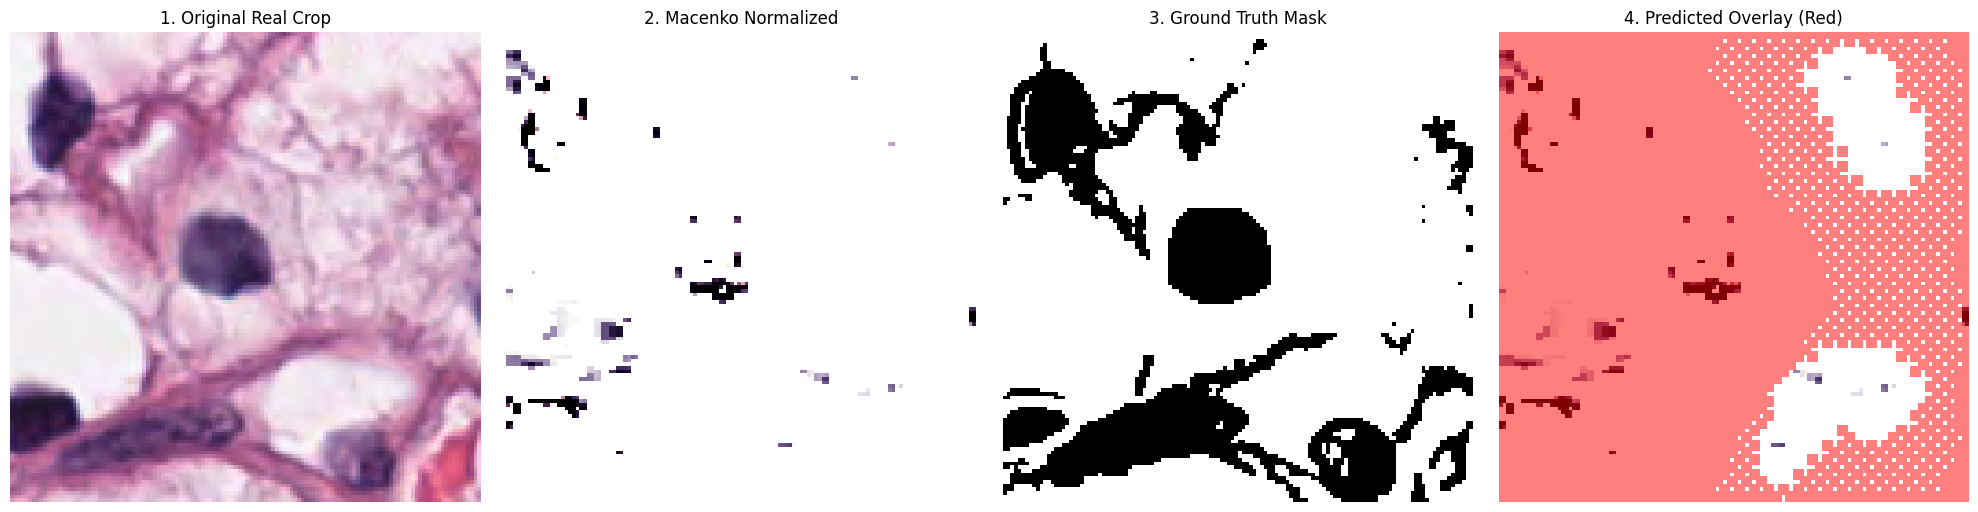

Accuracy Metric for this Crop:
 -> Dice Overlap Coefficient: 77.83%


In [71]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms

# 1. Embedded Stain Normalization Function
def normalize_stain_macenko(img, io=240, beta=0.15, alpha=1):
    img = np.array(img, dtype=np.float32)
    img_clipped = np.clip(img, 1.0, 255.0)
    od = -np.log10(img_clipped / io)
    od_flat = od.reshape(-1, 3)
    mask = np.any(od_flat > beta, axis=1)
    od_hat = od_flat[mask]
    if len(od_hat) < 100:
        return img.astype(np.uint8)
    cov = np.cov(od_hat, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    v = eigvecs[:, [2, 1]]
    proj = np.dot(od_hat, v)
    angles = np.arctan2(proj[:, 1], proj[:, 0])
    min_angle = np.percentile(angles, alpha)
    max_angle = np.percentile(angles, 100 - alpha)
    v_h = np.dot(v, np.array([np.cos(min_angle), np.sin(min_angle)]))
    v_e = np.dot(v, np.array([np.cos(max_angle), np.sin(max_angle)]))
    stain_matrix = np.array([v_e, v_h]).T if v_h[0] < v_e[0] else np.array([v_h, v_e]).T
    stain_matrix_inv = np.linalg.pinv(stain_matrix)
    concentration = np.dot(stain_matrix_inv, od_flat.T)
    max_concentration = np.percentile(concentration, 99, axis=1, keepdims=True)
    ref_stain_matrix = np.array([[0.5626, 0.2137], [0.7201, 0.8010], [0.4062, 0.5580]])
    ref_max_concentration = np.array([[1.9705], [1.0308]])
    normalized_concentration = concentration * (ref_max_concentration / (max_concentration + 1e-8))
    normalized_od = np.dot(ref_stain_matrix, normalized_concentration)
    normalized_img = io * np.power(10, -normalized_od)
    normalized_img = normalized_img.T.reshape(img.shape)
    return np.clip(normalized_img, 0.0, 255.0).astype(np.uint8)

# 2. Setup Device
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device set to: {device}")

# 3. AUTO-INITIALIZE MODEL IF MISSING
if 'model' not in globals():
    print("⚠️ 'model' was not found in memory. Automatically initializing a new ResNetUNet...")
    try:
        from unet_model import ResNetUNet
        model = ResNetUNet(n_class=1).to(device)
        print("✅ New model initialized! (Note: Run your training loop cell to get high accuracy).")
    except ImportError:
        raise ModuleNotFoundError("Could not find 'unet_model.py'. Please run the %%writefile cells at the top of your notebook first.")

# 4. Get list of all test slides
real_image_paths = sorted(glob.glob("/kaggle/input/datasets/ayush02102001/tnbc-seg/Kumar/kumar/test_same/Images/*.tif"))
real_mask_paths = sorted(glob.glob("/kaggle/input/datasets/ayush02102001/tnbc-seg/Kumar/kumar/test_same/Overlay/*.png"))

if len(real_image_paths) == 0:
    real_image_paths = sorted(glob.glob("/kaggle/input/**/test_same/Images/*.tif", recursive=True))
    real_mask_paths = sorted(glob.glob("/kaggle/input/**/test_same/Overlay/*.png", recursive=True))

if len(real_image_paths) == 0:
    raise FileNotFoundError("MoNuSeg test slides not found. Ensure the dataset is mounted.")

# 5. RANDOM SELECTION GENERATOR
random_slide_idx = np.random.randint(0, len(real_image_paths))
img_path = real_image_paths[random_slide_idx]
mask_path = real_mask_paths[random_slide_idx]

real_slide = cv2.imread(img_path)
real_slide = cv2.cvtColor(real_slide, cv2.COLOR_BGR2RGB)
real_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
real_mask = (real_mask > 127).astype(np.uint8)

h, w, _ = real_slide.shape

# Pick a random crop location
cy = np.random.randint(64, h - 64)
cx = np.random.randint(64, w - 64)

crop_img = real_slide[cy-64:cy+64, cx-64:cx+64]
crop_gt_mask = real_mask[cy-64:cy+64, cx-64:cx+64]

print(f"🎲 Random Selection:")
print(f" -> Slide Index: [{random_slide_idx}] ({os.path.basename(img_path)})")
print(f" -> Crop Center: ({cx}, {cy})")
print("-" * 50)

# 6. Stain Normalization
try:
    normalized_img = normalize_stain_macenko(crop_img)
    processed_img = Image.fromarray(normalized_img)
except:
    processed_img = Image.fromarray(crop_img)
    normalized_img = crop_img

# 7. U-Net Inference & Post-processing
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = eval_transform(processed_img).unsqueeze(0).to(device)

THRESHOLD = 0.38         # Adjust to tune boundary thickness
DILATION_ITERATIONS = 1  # Expands mask boundary (0 = off)

model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probabilities = torch.sigmoid(outputs).squeeze().cpu().numpy()
    
    binary_mask = (probabilities > THRESHOLD).astype(np.uint8)
    if DILATION_ITERATIONS > 0:
        kernel = np.ones((3, 3), np.uint8)
        binary_mask = cv2.dilate(binary_mask, kernel, iterations=DILATION_ITERATIONS)

# 8. Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(crop_img)
axes[0].set_title("1. Original Real Crop", fontsize=12)
axes[0].axis('off')

axes[1].imshow(normalized_img)
axes[1].set_title("2. Macenko Normalized", fontsize=12)
axes[1].axis('off')

axes[2].imshow(crop_gt_mask, cmap='gray')
axes[2].set_title("3. Ground Truth Mask", fontsize=12)
axes[2].axis('off')

overlay = np.copy(normalized_img)
overlay[binary_mask == 1] = [255, 0, 0]
blended = (normalized_img * 0.5 + overlay * 0.5).astype(np.uint8)

axes[3].imshow(blended)
axes[3].set_title("4. Predicted Overlay (Red)", fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 9. Print Dice Score
intersection = np.sum((binary_mask == 1) & (crop_gt_mask == 1))
union_sum = np.sum(binary_mask) + np.sum(crop_gt_mask)
dice = (2.0 * intersection) / (union_sum + 1e-8)
print(f"Accuracy Metric for this Crop:")
print(f" -> Dice Overlap Coefficient: {dice * 100:.2f}%")